In [3]:
import pandas as pd
columns = [
    'duration',
    'protocol_type',
    'service',
    'flag',
    'src_bytes',
    'dst_bytes',
    'land',
    'wrong_fragment',
    'urgent',
    'hot',
    'num_failed_logins',
    'logged_in',
    'num_compromised',
    'root_shell',
    'su_attempted',
    'num_root',
    'num_file_creations',
    'num_shells',
    'num_access_files',
    'num_outbound_cmds',
    'is_host_login',
    'is_guest_login',
    'count',
    'srv_count',
    'serror_rate',
    'srv_serror_rate',
    'rerror_rate',
    'srv_rerror_rate',
    'same_srv_rate',
    'diff_srv_rate',
    'srv_diff_host_rate',
    'dst_host_count',
    'dst_host_srv_count',
    'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate',
    'attack',
    'difficulty'
]

In [4]:
train = pd.read_csv(
    "KDDTrain+.txt",
    names=columns
)

test = pd.read_csv(
    "KDDTest+.txt",
    names=columns
)

In [5]:
train.head()

train.shape

train["attack"].value_counts()

attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [6]:
train.shape

(125973, 43)

In [7]:
train["attack"].value_counts().head(20)

attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
Name: count, dtype: int64

In [8]:
train["attack"] = train["attack"].apply(
    lambda x: 0 if x == "normal" else 1
)

test["attack"] = test["attack"].apply(
    lambda x: 0 if x == "normal" else 1
)

In [9]:
train["attack"].value_counts()

attack
0    67343
1    58630
Name: count, dtype: int64

In [10]:
train.isnull().sum().sum()

np.int64(0)

In [11]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [12]:
train = pd.get_dummies(
    train,
    columns=["protocol_type", "service", "flag"]
)

test = pd.get_dummies(
    test,
    columns=["protocol_type", "service", "flag"]
)

In [13]:
train, test = train.align(
    test,
    join="left",
    axis=1,
    fill_value=0
)

In [14]:
X_train = train.drop(
    ["attack", "difficulty"],
    axis=1
)

y_train = train["attack"]

In [15]:
X_test = test.drop(
    ["attack", "difficulty"],
    axis=1
)

y_test = test["attack"]

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

In [18]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [19]:
pred = rf.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(y_test, pred))

print(confusion_matrix(y_test, pred))

print(classification_report(y_test, pred))

Accuracy: 0.7730660042583393
[[9448  263]
 [4853 7980]]
              precision    recall  f1-score   support

           0       0.66      0.97      0.79      9711
           1       0.97      0.62      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.84      0.77      0.77     22544



In [21]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))

In [22]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
1,src_bytes,0.130225
2,dst_bytes,0.097538
120,flag_SF,0.086043
29,dst_host_srv_count,0.055434
25,same_srv_rate,0.054508
30,dst_host_same_srv_rate,0.049657
26,diff_srv_rate,0.041976
8,logged_in,0.041083
35,dst_host_srv_serror_rate,0.035796
31,dst_host_diff_srv_rate,0.033902


In [23]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [24]:
importance.head(10)

,Feature,Importance
1,src_bytes,0.130225
2,dst_bytes,0.097538
120,flag_SF,0.086043
29,dst_host_srv_count,0.055434
25,same_srv_rate,0.054508
30,dst_host_same_srv_rate,0.049657
26,diff_srv_rate,0.041976
8,logged_in,0.041083
35,dst_host_srv_serror_rate,0.035796
31,dst_host_diff_srv_rate,0.033902


In [25]:
test.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,0,0,0,0,0,0,0,0,0,...,True,False,False,False,False,False,False,False,False,False
1,0,0,0,0,0,0,0,0,0,0,...,True,False,False,False,False,False,False,False,False,False
2,2,12983,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
3,0,20,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
4,1,0,15,0,0,0,0,0,0,0,...,False,True,False,False,False,False,False,False,False,False


In [29]:
# Autoencoder Based Anomaly Detection


In [34]:
from sklearn.preprocessing import MinMaxScaler

normal_train = train[train["attack"] == 0]

X_normal = normal_train.drop(
    ["attack", "difficulty"],
    axis=1
)

X_test_auto = test.drop(
    ["attack", "difficulty"],
    axis=1
)

y_test_auto = test["attack"]

scaler = MinMaxScaler()

X_normal = scaler.fit_transform(X_normal)

X_test_auto = scaler.transform(X_test_auto)

print(X_normal.shape)
print(X_test_auto.shape)

(67343, 122)
(22544, 122)


In [35]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_dim = X_normal.shape[1]

input_layer = Input(shape=(input_dim,))

encoder = Dense(64, activation="relu")(input_layer)
encoder = Dense(32, activation="relu")(encoder)
encoder = Dense(16, activation="relu")(encoder)

decoder = Dense(32, activation="relu")(encoder)
decoder = Dense(64, activation="relu")(decoder)
decoder = Dense(input_dim, activation="sigmoid")(decoder)

autoencoder = Model(
    inputs=input_layer,
    outputs=decoder
)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

E0000 00:00:1781405085.631201    6292 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 122)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         7,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 122)            │         7,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,066 (82.29 KB)

 Trainable params: 21,066 (82.29 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = autoencoder.fit(
    X_normal,
    X_normal,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0420 - val_loss: 0.0093
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0063 - val_loss: 0.0042
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0037 - val_loss: 0.0034
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0029 - val_loss: 0.0028
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 9/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 10/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 11/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 12/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [37]:
import numpy as np

reconstructed = autoencoder.predict(
    X_test_auto
)

mse = np.mean(
    np.square(
        X_test_auto - reconstructed
    ),
    axis=1
)

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [59]:
threshold = np.percentile(
    mse,
    80
)

print("Threshold:", threshold)

Threshold: 0.04759215051827603


In [60]:
pred_auto = (
    mse > threshold
).astype(int)

In [61]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print(
    "Accuracy:",
    accuracy_score(
        y_test_auto,
        pred_auto
    )
)

print(
    confusion_matrix(
        y_test_auto,
        pred_auto
    )
)

print(
    classification_report(
        y_test_auto,
        pred_auto
    )
)

Accuracy: 0.6256210078069553
[[9653   58]
 [8382 4451]]
              precision    recall  f1-score   support

           0       0.54      0.99      0.70      9711
           1       0.99      0.35      0.51     12833

    accuracy                           0.63     22544
   macro avg       0.76      0.67      0.60     22544
weighted avg       0.79      0.63      0.59     22544



In [62]:
# Model Comparison


In [63]:
comparison = {
    "Model": [
        "Random Forest",
        "Autoencoder"
    ],
    "Type": [
        "Supervised",
        "Unsupervised"
    ],
    "Accuracy": [
        0.773,
        accuracy_score(
            y_test_auto,
            pred_auto
        )
    ]
}

pd.DataFrame(comparison)

,Model,Type,Accuracy
0,Random Forest,Supervised,0.773000
1,Autoencoder,Unsupervised,0.625621


In [64]:
import pandas as pd

results = pd.DataFrame({
    "mse": mse,
    "actual": y_test_auto
})

results.groupby("actual")["mse"].describe()

,count,mean,std,min,25%,50%,75%,max
actual,,,,,,,,
0,9711.0,0.002836,0.008932,0.000004,0.000027,0.000058,0.000219,0.087987
1,12833.0,0.033749,0.021270,0.000011,0.015079,0.034850,0.055014,0.087922


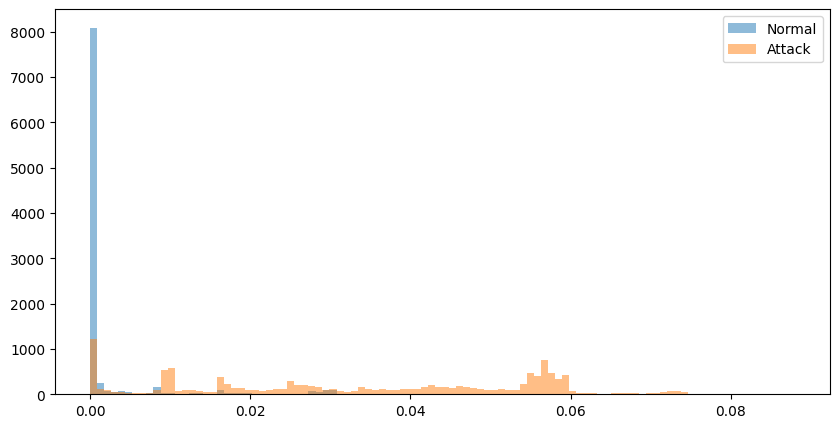

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    results[results["actual"]==0]["mse"],
    bins=100,
    alpha=0.5,
    label="Normal"
)

plt.hist(
    results[results["actual"]==1]["mse"],
    bins=100,
    alpha=0.5,
    label="Attack"
)

plt.legend()
plt.show()

In [66]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [67]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [68]:
import pickle

pickle.dump(
    X_train.columns.tolist(),
    open("columns.pkl", "wb")
)

In [69]:
sample = X_test.head(100)

sample.to_csv(
    "sample_network_traffic.csv",
    index=False
)

print("Saved!")

Saved!


In [70]:
normal_sample = X_test[
    y_test == 0
].head(100)

normal_sample.to_csv(
    "normal_traffic.csv",
    index=False
)

In [71]:
attack_sample = X_test[
    y_test == 1
].head(100)

attack_sample.to_csv(
    "attack_traffic.csv",
    index=False
)

In [72]:
normal = X_test[
    y_test == 0
].head(50)

attack = X_test[
    y_test == 1
].head(50)

demo = pd.concat(
    [normal, attack]
)

demo.to_csv(
    "demo_network_traffic.csv",
    index=False
)